위키피디아 페이지뷰의 트래픽 예측하는 대회   
여기서는 WaveNet 구조 기반의 딥러닝 모델을 활용함.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set()

In [64]:
df = pd.read_csv('train_1.csv')
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145063 entries, 0 to 145062
Columns: 551 entries, Page to 2016-12-31
dtypes: float64(550), object(1)
memory usage: 609.8+ MB


날짜 범위 확인 ㄱㄱ

In [67]:
data_start_date = df.columns[1]
data_end_date = df.columns[-1]
print('Data ranges from %s to %s.' %(data_start_date, data_end_date))

Data ranges from 2015-07-01 to 2016-12-31.


1년 6개월치구만

시계열 데이터 무작위로 6개 선택해서 로그스케일로 시각화했대

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31435 (\N{CJK UNIFIED IDEOGRAPH-7ACB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21561 (\N{CJK UNIFIED IDEOGRAPH-5439}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30000 (\N{CJK UNIFIED IDEOGRAPH-7530}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) Arial.
  fig.canvas.print_figure(byte

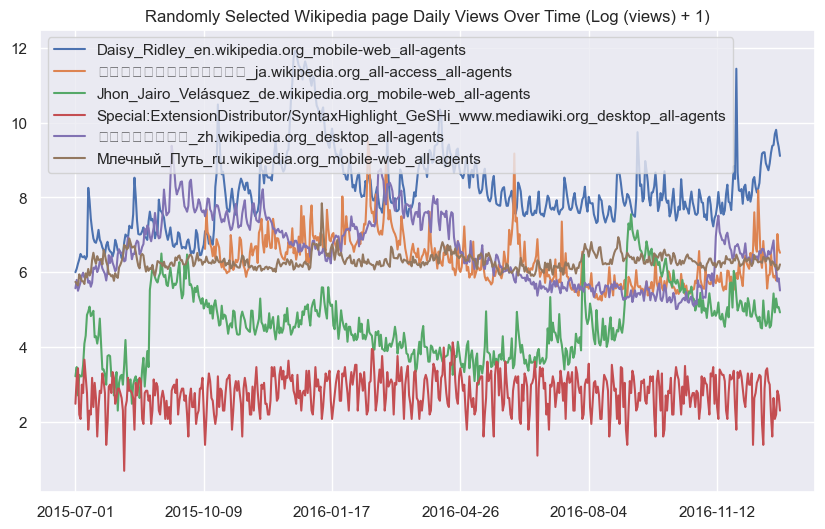

In [70]:
def plot_random_series(df, n_series):

    sample = df.sample(n_series, random_state = 52)
    page_labels = sample['Page'].tolist()
    series_samples = sample.loc[:,data_start_date:data_end_date]

    plt.figure(figsize=(10,6))

    for i in range(series_samples.shape[0]):
        np.log1p(pd.Series(series_samples.iloc[i]).astype(np.float64)).plot(linewidth=1.5)

        plt.title('Randomly Selected Wikipedia page Daily Views Over Time (Log (views) + 1)')
        plt.legend(page_labels)

plot_random_series(df,6)
plt.show()

In [71]:
from datetime import timedelta

pred_steps = 60
pred_length = timedelta(pred_steps)

first_day = pd.to_datetime(data_start_date)
last_day = pd.to_datetime(data_end_date)

val_pred_start = last_day - pred_length + timedelta(1)
val_pred_end = last_day

train_pred_start = val_pred_start - pred_length
train_pred_end = val_pred_start - timedelta(days=1)

60일치 예측하고, val은 검증데이터 구간, train은 훈련데이터 구간   
가장 끝쪽 60일은 검증하고, 그 전 60일은 학습용으로 사용

In [73]:
# 학습 구간 시작 전까지의 길이
enc_length = train_pred_start - first_day

# 학습용 
# train pred start ~ train pred end 예측용
train_enc_start = first_day
train_enc_end = train_enc_start + enc_length - timedelta(1)

# 검증용 
# val pred start ~ val pred end 예측용
val_enc_start = train_enc_start + pred_length
val_enc_end = val_enc_start + enc_length - timedelta(1) 

학습 - 검증 간 입력데이터와 예측데이터의 길이를 같게 하기 위한 과정인듯 ?

In [75]:
print('Train encoding:', train_enc_start, '-', train_enc_end)
print('Train prediction:', train_pred_start, '-', train_pred_end, '\n')
print('Val encoding:', val_enc_start, '-', val_enc_end)
print('Val prediction:', val_pred_start, '-', val_pred_end)

print('\nEncoding interval:', enc_length.days)
print('Prediction interval:', pred_length.days)

Train encoding: 2015-07-01 00:00:00 - 2016-09-02 00:00:00
Train prediction: 2016-09-03 00:00:00 - 2016-11-01 00:00:00 

Val encoding: 2015-08-30 00:00:00 - 2016-11-01 00:00:00
Val prediction: 2016-11-02 00:00:00 - 2016-12-31 00:00:00

Encoding interval: 430
Prediction interval: 60


그래서 60일을 예측하기 위해서 430일치의 데이터를 인코딩한다~

In [77]:
# 날짜를 datetime형식으로 바꾸고, 인덱스 번호랑 맵핑
date_to_index = pd.Series(index=pd.Index([pd.to_datetime(c) for c in df.columns[1:]]), data = [i for i in range(len(df.columns[1:]))])

# 날짜별로 시계열 데이터만 추출
series_array = df[df.columns[1:]].values

# 시작일 ~ 종료일까지 날짜 범위에 맞는 시계열 블록 추출
def get_time_block_series(series_array, date_to_index, start_date, end_date):
    start_idx = date_to_index[start_date]
    end_idx = date_to_index[end_date]
    return series_array[:, start_idx:end_idx+1]

# 입력값 전처리
# 로그변환, 결측치 대치, 평균정규화, shape 변경(cnn 입력 형태)
def transform_series_encode(series_array):
    series_array = np.log1p(np.nan_to_num(series_array))
    series_mean = series_array.mean(axis=1).reshape(-1,1)
    series_array == series_array - series_mean
    series_array = series_array.reshape((series_array.shape[0], series_array.shape[1], 1))
    return series_array, series_mean

# y값 전처리 
# 로그화, 결측치대치, 평균정규화
def transform_series_decode(series_array, encode_series_mean):
    series_array = np.log1p(np.nan_to_num(series_array))
    series_array = series_array - encode_series_mean
    series_array = series_array.reshape((series_array.shape[0],series_array.shape[1], 1))
    return series_array

WaveNet 모델의 완전한 형태로, 원래는 오디오를 위한 생성모델로 설계됨.   
그것을 넘어 모든 시계열 예측 문제에 일반화하여 적용가능.   
과도하게 많은 학습 파라미터 없이도 장기적인 의존성을 잘 포착할 수 있는 구조 제공.   
dilated causal convolution layer(팽창된 인과적 합성곱 계층)을 핵심구성 요소로 가지며   
시간의 흐름을 올바르게 처리하며, 층이 깊어질수록 출록의 수용영역(receptive field)이 지수적으로 증가하게 됨   

모델 구조 설명   
1)6개의 dilated causal convolution layer
    시계열을 처리하는 합성곱 층 16개..   
    각층은 causal convolution이고, dilated(간격 있는) 형태   
    causal : 과거 정보만 사용해서 미래 예측   
    dilated : 1,2,4,8... 식으로 건너뛰며 보는 구조 -> 더 넓음 범위까지 볼 수 있음   

2)필터수, 너비   
    각 블록에 너비 2짜리 필터를 32개 사용   
    한번에 2개의 시점을 보고 특징 추출   
    필터수 32개는 동시에 32개의 다른 패턴 찾기   

3)dilation rate가 지수적으로 증가함   
    블록 쌓을 때 1,2,4,8 ... 128로 증가   
    그리고 다시 1,2,4,8 ... 128로 증가 반복   
    긴 과거까지 한번에 커버 가능   

4)Gated activation
    relu대신 게이트방식 사용
    입력을 필터와 게이트 두갈래로 나눔... (??)   

5)Resiual & Skip connection   
    residual : 층을 지나가면서 원래 입력을 더해줌 -> 학습 잘됨   
    skip : 중간중간 나온 출력을 다 모아서 나중에 최종출력에 사용.   

6 출력 시퀀스에서 마지막 60개만 사용함   
    예측구간이 60일이ㅣ까 60개만 씀.   

7 teacher forcing 사용
학습할때에는 이전 예측값이 아니라 정답을 넣어줌.   
학습이 훨씬 바르고 안정적으로..   


테스트할때 (추론)   
정답이 없으니까.   
모델이 예측한 값 저장하고   
그 값을 다시 다음 시점의 입력으로 사용하고   
이과정 60번 반복해서 예측 시퀀스 만듦   

뭔 개소리죠?

In [85]:
from keras.models import Model
from keras.layers import Input, Conv1D, Dense, Activation, Dropout, Lambda, Multiply, Add, Concatenate
from keras.optimizers import Adam
from tensorflow.keras.optimizers import Adam

# 하이퍼 파라미터
# 필터개수
n_filters = 32 
# 커널 사이즈
filter_width = 2
# dilated convolution적용 지수적 확장률 설정?
dilation_rates = [2**i for i in range(8)] * 2 

# 입력 시계열 (시간길이(가변), 변수 1개)
history_seq = Input(shape=(None, 1))
x = history_seq
# 이건 skip connection 추가해서 나중에 합산
skips = []

# 여기가 wavenet
for dilation_rate in dilation_rates:
    # 1x1 컨볼루션.
    x = Conv1D(16, 1, padding='same', activation='relu')(x) 

    # Gated activation
    # tanh 게이트
    x_f = Conv1D(filters=n_filters,
                 kernel_size=filter_width, 
                 padding='causal',
                 dilation_rate=dilation_rate)(x)
    # sigmoid 게이트
    x_g = Conv1D(filters=n_filters,
                 kernel_size=filter_width, 
                 padding='causal',
                 dilation_rate=dilation_rate)(x)
    # 비선형 활성화 (두 값 곱해서 정보 흐름 조절)
    z = Multiply()([Activation('tanh')(x_f),
                    Activation('sigmoid')(x_g)])
    # z를 다시 1x1로 줄임
    z = Conv1D(16, 1, padding='same', activation='relu')(z)
    # x에다가 z더함 (원래정보 + 새 정보)
    x = Add()([x, z])    
    # z저장.
    skips.append(z)
# 이과정을 1,2 ~ 128까지 반복
# receptive field가 커져서 긴 시계열 패턴도 학습 가능
# receptive field란, 하나의 출력값이 참조한 입력의 범위
# 생각해보니까 dilation 교수님이 뭐 인터넷으로 보여주는거 보고 궁금해서 뭔지 찾아봤었네.....(설명해 상민아)

# 위에서 나온 skip에 relu 적용
# WaveNet의 핵심 중 하나: skip connections의 합산 후 후처리 라는데........?
out = Activation('relu')(Add()(skips))
# 1x1 컨볼루션 적용, 활성화함수로 relu 적용하고, 드롭아웃 0.2
out = Conv1D(128, 1, padding='same')(out)
out = Activation('relu')(out)
out = Dropout(.2)(out)
# 최종 출력.
out = Conv1D(1, 1, padding='same')(out)

# 슬라이싱 함수
def slice(x, seq_length):
    return x[:,-seq_length:,:]

# 마지막 60일치 예측결과로 사용
pred_seq_train = Lambda(slice, arguments={'seq_length':60})(out)

# historyseq, predseqtrain 관계 모델 구성
# 과거 시계열 => 미래 60일 
model = Model(history_seq, pred_seq_train)
model.compile(Adam(), loss='mean_absolute_error')

모델 확인

In [93]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_66 (Conv1D)  │ (None, None, 16)  │         32 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_67 (Conv1D)  │ (None, None, 32)  │      1,056 │ conv1d_66[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_68 (Conv1D)  │ (None, None, 32)  │      1,056 │ conv1d_66[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_34       │ (None, None, 32)  │          0 │ conv1d_67[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_35       │ (None, None, 32)  │          0 │ conv1d_68[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_16         │ (None, None, 32)  │          0 │ activation_34[0]… │
│ (Multiply)          │                   │            │ activation_35[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_69 (Conv1D)  │ (None, None, 16)  │        528 │ multiply_16[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, None, 16)  │          0 │ conv1d_66[0][0],  │
│                     │                   │            │ conv1d_69[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_70 (Conv1D)  │ (None, None, 16)  │        272 │ add_17[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_71 (Conv1D)  │ (None, None, 32)  │      1,056 │ conv1d_70[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_72 (Conv1D)  │ (None, None, 32)  │      1,056 │ conv1d_70[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, None, 32)  │          0 │ conv1d_71[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, None, 32)  │          0 │ conv1d_72[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_17         │ (None, None, 32)  │          0 │ activation_36[0]… │
│ (Multiply)          │                   │            │ activation_37[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_73 (Conv1D)  │ (None, None, 16)  │        528 │ multiply_17[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, None, 16)  │          0 │ conv1d_70[0][0],  │
│                     │                   │            │ conv1d_73[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_74 (Conv1D)  │ (None, None, 16)  │        272 │ add_18[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_75 (Conv1D)  │ (None, None, 32)  │      1,056 │ conv1d_74[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_76 (Conv1D)  │ (None, None, 32)  │      1,056 │ conv1d_74[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 48,657 (190.07 KB)

 Trainable params: 48,657 (190.07 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
# 하이퍼 파라미터
# 학습 샘플 수
first_n_samples = 120000
# 미니배치 크기 2048
batch_size = 2**11
# 에포크 10
epochs = 10

# 데이터 설정하고..
encoder_input_data = get_time_block_series(series_array, date_to_index, train_enc_start, train_enc_end)[:first_n_samples]
encoder_input_data, encode_series_mean = transform_series_encode(encoder_input_data)

decoder_target_data = get_time_block_series(series_array, date_to_index, 
                                            train_pred_start, train_pred_end)[:first_n_samples]
decoder_target_data = transform_series_decode(decoder_target_data, encode_series_mean)

lagged_target_history = decoder_target_data[:,:-1,:1]
encoder_input_data = np.concatenate([encoder_input_data, lagged_target_history], axis=1)

# 최적화모델 아담으로하고 손실함수는 mae
model.compile(Adam(), loss='mean_absolute_error')

# 모델 피팅. 8:2로 스플릿
history = model.fit(encoder_input_data, decoder_target_data,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_split=0.2)  

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 335s 7s/step - loss: 0.5989 - val_loss: 0.3454
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 310s 7s/step - loss: 0.3659 - val_loss: 0.3227
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 310s 7s/step - loss: 0.3401 - val_loss: 0.3068
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 270s 6s/step - loss: 0.3232 - val_loss: 0.2809
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 290s 6s/step - loss: 0.3042 - val_loss: 0.2700
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 291s 6s/step - loss: 0.2947 - val_loss: 0.2668
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 293s 6s/step - loss: 0.2909 - val_loss: 0.2625
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 302s 6s/step - loss: 0.2873 - val_loss: 0.2596
Epoch 9/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 297s 6s/step - loss: 0.2848 - val_loss: 0.2581
Epoch 10/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 300s 6s/step - loss: 0.2812 - val_loss: 0.2551


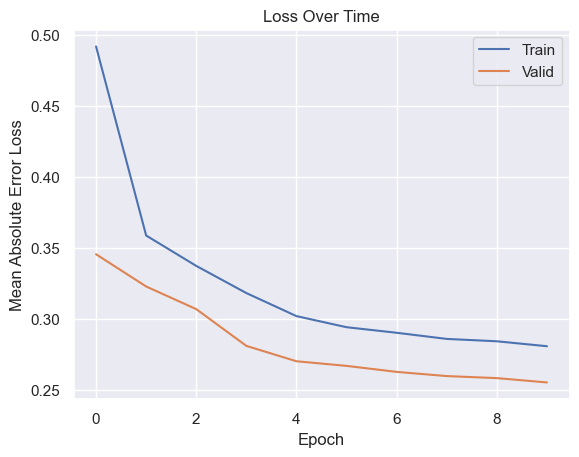

In [97]:
# 손실함수 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error Loss')
plt.title('Loss Over Time')
plt.legend(['Train','Valid'])
plt.show()

In [98]:
# 미래 예측하는 함수
def predict_sequence(input_sequence):
    # 입력시퀀스 복사해서 쓰네?
    history_sequence = input_sequence.copy()
    # 빈배열 생성
    pred_sequence = np.zeros((1,pred_steps,1))
    # 60일치 반복
    for i in range(pred_steps):
        last_step_pred = model.predict(history_sequence)[0,-1,0]
        pred_sequence[0,i,0] = last_step_pred
        
        history_sequence = np.concatenate([history_sequence, 
                                           last_step_pred.reshape(-1,1,1)], axis=1)
    return pred_sequence

In [99]:
# 입력데이터
encoder_input_data = get_time_block_series(series_array, date_to_index, val_enc_start, val_enc_end)
encoder_input_data, encode_series_mean = transform_series_encode(encoder_input_data)

# 타겟 데이터 
decoder_target_data = get_time_block_series(series_array, date_to_index, val_pred_start, val_pred_end)
decoder_target_data = transform_series_decode(decoder_target_data, encode_series_mean)

# 둘다 전처리하는 과정

In [100]:
# 예측하고 그림그리기~ㅡ
def predict_and_plot(encoder_input_data, decoder_target_data, sample_ind, enc_tail_len=50):

    encode_series = encoder_input_data[sample_ind:sample_ind+1,:,:] 
    pred_series = predict_sequence(encode_series)
    
    encode_series = encode_series.reshape(-1,1)
    pred_series = pred_series.reshape(-1,1)   
    target_series = decoder_target_data[sample_ind,:,:1].reshape(-1,1) 
    
    encode_series_tail = np.concatenate([encode_series[-enc_tail_len:],target_series[:1]])
    x_encode = encode_series_tail.shape[0]
    
    plt.figure(figsize=(10,6))   
    
    plt.plot(range(1,x_encode+1),encode_series_tail)
    plt.plot(range(x_encode,x_encode+pred_steps),target_series,color='orange')
    plt.plot(range(x_encode,x_encode+pred_steps),pred_series,color='teal',linestyle='--')
    
    plt.title('Encoder Series Tail of Length %d, Target Series, and Predictions' % enc_tail_len)
    plt.legend(['Encoding Series','Target Series','Predictions'])
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/st

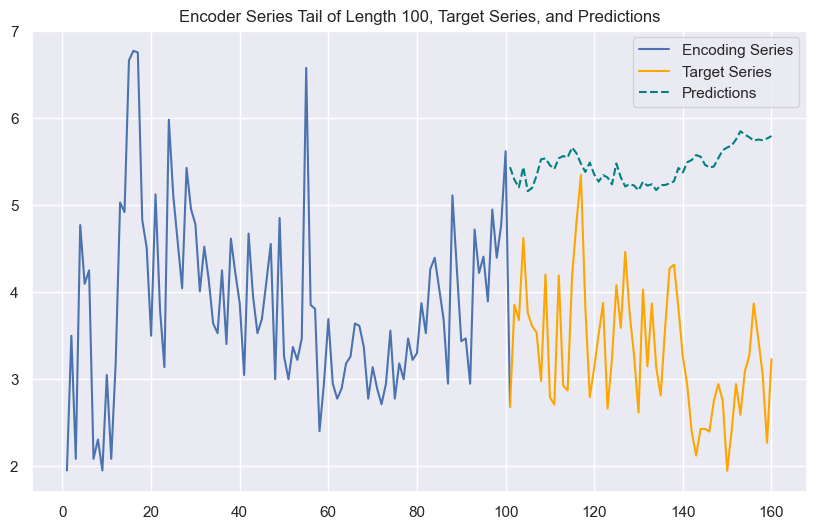

In [101]:
predict_and_plot(encoder_input_data, decoder_target_data, sample_ind=24, enc_tail_len=100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/ste

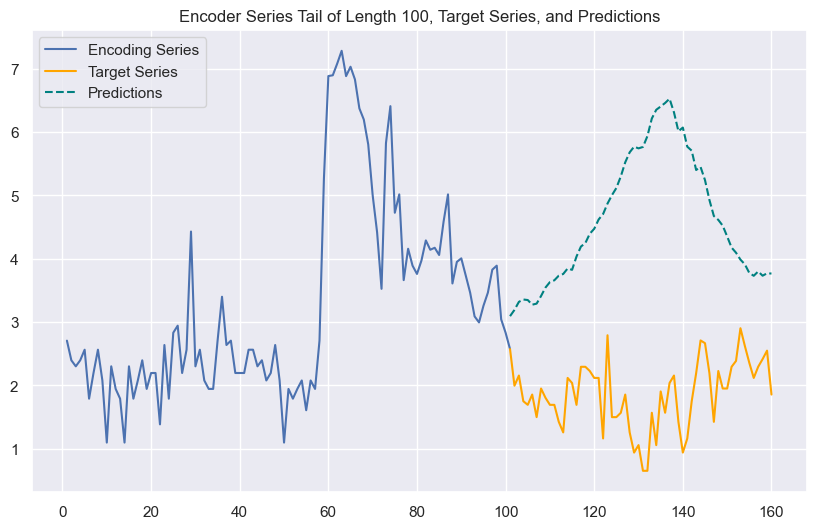

In [102]:
predict_and_plot(encoder_input_data, decoder_target_data, sample_ind=4000, enc_tail_len=100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1

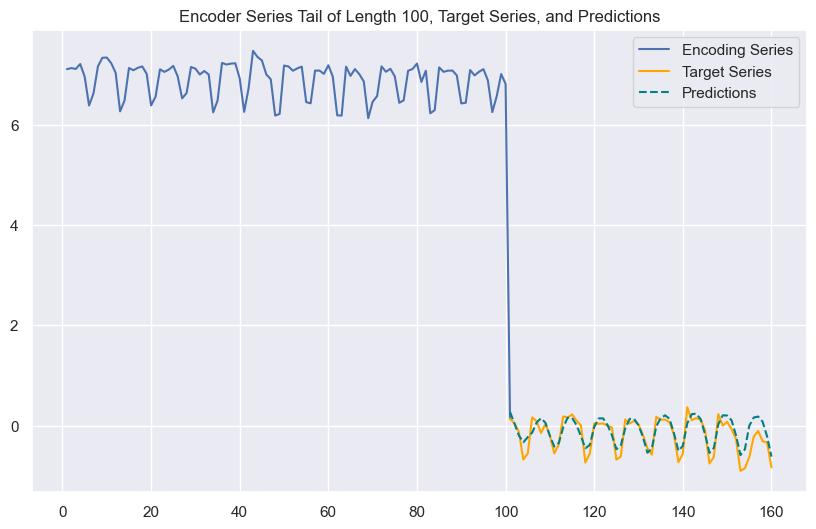

In [103]:
predict_and_plot(encoder_input_data, decoder_target_data, 
                 sample_ind=68000, enc_tail_len=100)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


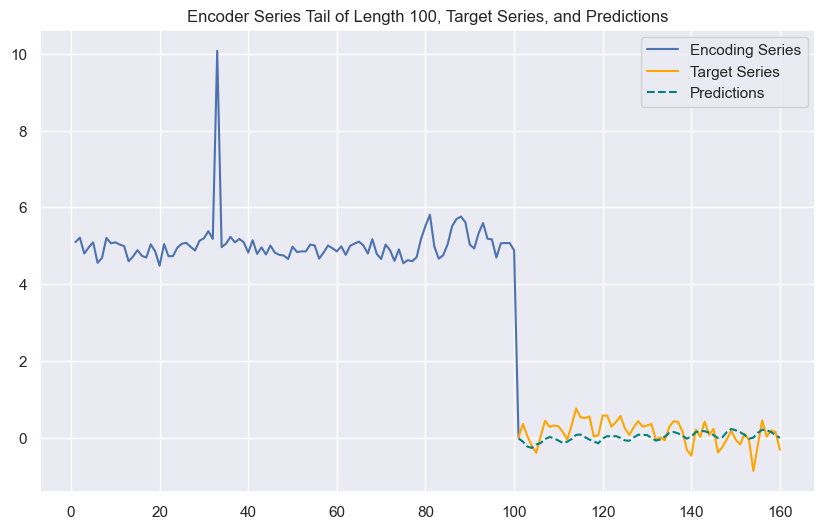

In [104]:
predict_and_plot(encoder_input_data, decoder_target_data, 
                 sample_ind=6007, enc_tail_len=100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1

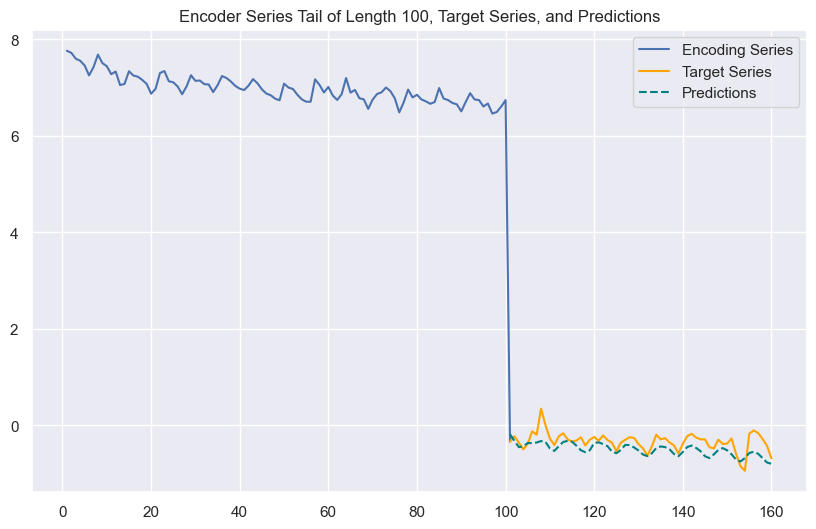

In [105]:
predict_and_plot(encoder_input_data, decoder_target_data, 
                 sample_ind=70450, enc_tail_len=100)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

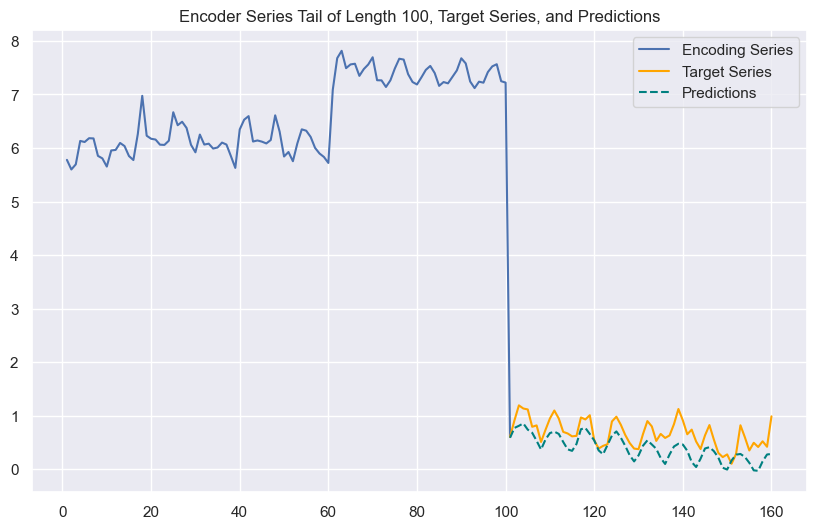

In [106]:
predict_and_plot(encoder_input_data, decoder_target_data, 
                 sample_ind=16551, enc_tail_len=100)

전반적으로 보면 시계열적인 패턴 자체는 학습을 좀 잘한거 같다~